In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [3]:
def interp_mat(out, grid_in): # interpolates from grid_in to out
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
    return np.concatenate(
        [1*(out[...,:1]>=grid_in[...,:1])-slope[...,:1],
         -np.diff(slope, axis=-1),
         slope[...,-1:]-1*(out[...,-1:]>grid_in[...,-1:])],
        axis=-1)

# Setup

## Load Matlab Run

In [4]:
runMat = scipy.io.loadmat('matlab/Firn Ice Model/Firn Model - CIC Forward Model v5.0/Runs/Run2026-07-21_08h59m.mat')
runMat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Jul 21 09:00:16 2026',
 '__version__': '1.0',
 '__globals__': [],
 'Acc': array([[0.032]]),
 'None': MatlabOpaque([(b'An2', b'MCOS', b'matlab.graphics.shape.TextBox', array([[3707764736],
                      [         2],
                      [         1],
                      [         1],
                      [         1],
                      [         2]], dtype=uint32))                                    ],
              dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]),
 'ApplyUncert': array([[0]], dtype=uint8),
 'Apply_14CO_adj': array([[0]], dtype=uint8),
 'C14CH4_color': array([[0, 1, 0]], dtype=uint8),
 'C14CO2_color': array([[0.2 , 0.73, 1.  ]]),
 'C14CO_color': array([[0.8, 0.8, 0. ]]),
 'C14CO_const': array([[12]], dtype=uint8),
 'C14CO_const_u': array([[2]], dtype=uint8),
 'C14CO_hist': array(['constant'], dtype='<U8'),
 'C14CO_hist_dX_lin': array([[-0.6]]),
 'C14CO_hist_dX_pct': arr

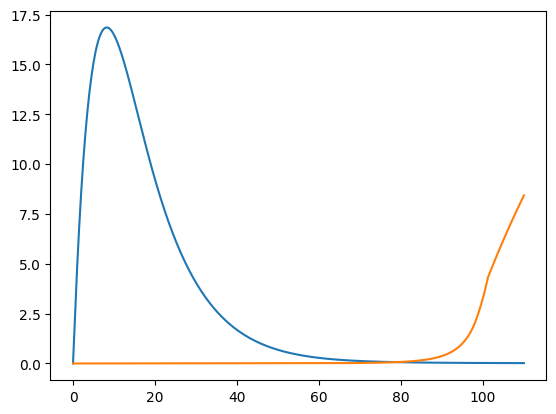

In [5]:
plt.plot(runMat['z'], runMat['C14_grains'][:,-1,1])
plt.plot(runMat['z'], runMat['C14_closed'][:,-1,1])

## Set Parameters

In [6]:
#COS_partition = np.array(
#    [#CO2         CO          CH4
#    [0.686307104, 0.31125305, 0.002439846], # neutron
#    [0.686307104, 0.31125305, 0.002439846], # neg muon
#    [0.686307104, 0.31125305, 0.002439846], # fast muon
#])
COS_partition = runMat['COS_partition']

#L = np.array([1, 7e-4])
L = np.array([1,runMat['leakage'][0,0]['closed'][0,1]])
Res = runMat['Res_partition'][0]

#f_factors = np.array([1., 0.06, 0.08])
#P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]]) * COS_partition[0,1]
P0_tuning = runMat['P0_tuning'][0] * COS_partition[0,1]
f_factors = P0_tuning * np.array([1/COS_partition[0,1], 1, 1])
f_factors

array([1.03 , 0.065, 0.07 ])

## Load Propagator Model

In [7]:
Prop_DC = Propagator()

## Load Firn Model

In [8]:
t = time()
#Dome_C = Accumulation_Site(t_resol=10)
Dome_C = Accumulation_Site(z_end=runMat['z_end'][0,0],
                           t_end=runMat['t_end'][0,0],
                           #t_resol=10,
                           C14CO_const=int(runMat['C14CO_const'][0,0]),
                           Acc=runMat['Acc'][0,0],
                          )

# caculate cosmogenic 14C in reservoirs w/ Leakage rates L
C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Dome_C.Calc_14C_ice(L=L)

# calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Dome_C.Calc_profiles(C14_leak_open, analytic=True)
print(time()-t)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:219: RuntimeWarning: invalid value encountered in divide
  bubble_pres = np.sum((dscl * C * self.s)[None,:] * self.dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(self.s*(self.s_closed-self.s_closed[0]))
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:359: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:361: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*(COS_age+COS_dt)) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:597: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)


0.009404182434082031
interpolating...


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 77.17it/s]


integrating...
  Calculated open and closed profiles for gas 1 out of 1
0.22957229614257812
0.2581920623779297


## Load Samples

In [9]:
pd_DomeC = pd.read_excel('DomeC 14CO data analysis current.xlsx', '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])
pd_DomeC

,"Mean depth, m","14CO, molec / g ice after all corrections","Error, 1 sigma","Mean gas age, yr before 1950","Mean gas age, Years before measurement date"
Sample,,,,,
14CO_UR_DC_FIRN_SAMPLE_1,34.000,46.438967,1.143309,NaN,NaN
14CO_UR_DC_FIRN_SAMPLE_2,54.500,28.289650,0.749249,NaN,NaN
14CO_UR_DC_FIRN_EXTRACTION_3,75.000,18.807095,0.543124,NaN,NaN
14CO_UR_DC_ICE_SAMPLE_1,110.000,18.669397,0.885088,434.483581,510.483581
14CO_UR_DC_ICE_SAMPLE_3,150.000,26.848805,0.679599,1901.485970,1977.485970
14CO_UR_DC_ICE_SAMPLE_4,170.000,28.480674,0.573240,2717.573599,2793.573599
14CO_UR_DC_ICE_SAMPLE_5,190.500,29.289987,0.601586,3323.027758,3399.027758
14CO_UR_DC_ICE_SAMPLE_6,211.000,29.666008,0.722400,4118.909061,4194.909061
14CO_UR_DC_ICE_SAMPLE_7,230.925,28.951245,0.655983,4761.798084,4837.798084


In [10]:
z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

## Setup Grids

In [11]:
Copy_Firn = True

In [12]:
# 14C decay constant [yr^-1]
if Copy_Firn:
    lambd = Dome_C.decay_gas['C14_CO']
else:
    lambd = Prop_DC.lambd
    #lambd = 1.216e-4 #yr^-1
lambd

0.00012096286440062901

(441,)


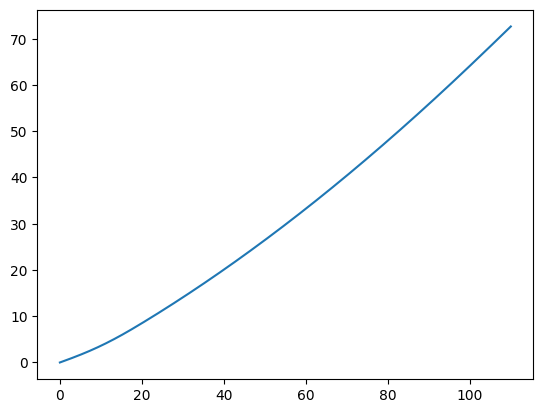

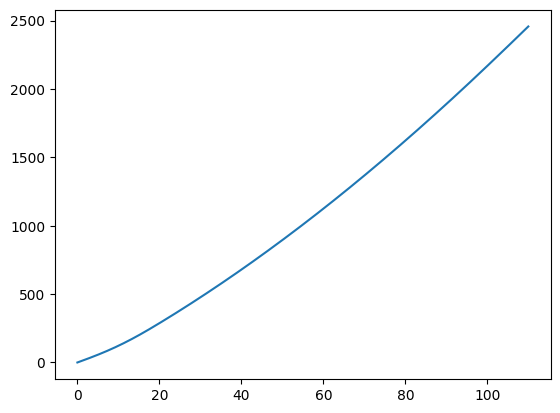

In [13]:
# age & depth interpolation grids [grid]
# used to interpolate between real depth, mass depth, and ice age
if Copy_Firn:
    z_grid = Dome_C.z
    h_grid = Dome_C.IceAge * Dome_C.Acc * Dome_C.rho_ice
    age_grid = Dome_C.IceAge
else:
    z_grid = Prop_DC.z_grid
    h_grid = Prop_DC.h_grid
    age_grid = Prop_DC.age_grid
    
print(z_grid.shape)

plt.plot(z_grid, h_grid)
plt.show()

plt.plot(z_grid, age_grid)
plt.show()

In [14]:
# Input (Production) Grids [grid]
# equally space in time / ice age
# used to track time dependent inputs
dt_p = 4
#t_end = 10000
t_end = runMat['t_end'][0,0]
t_p = np.arange(0, t_end+dt_p, dt_p)
t_p = t_p-t_p[-1]
t_p.shape

(751,)

In [15]:
dage_p = dt_p
age_p = np.arange(0, age_grid[-1]+1e-10, dage_p)
h_p = np.interp(age_p, age_grid, h_grid)
z_p = np.interp(age_p, age_grid, z_grid)
h_p.shape

(615,)

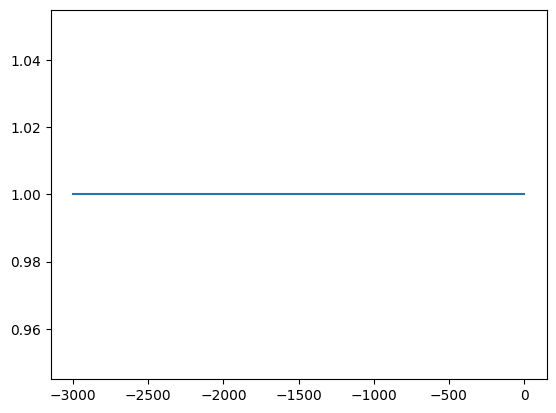

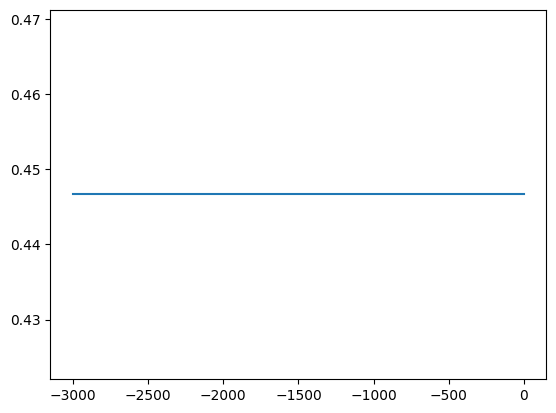

In [16]:
# GCR Flux History
phi = np.ones(len(t_p))
plt.plot(t_p, phi)
plt.show()

# Atmospheric 14CO history
gas_history = Dome_C.gas_history['C14_CO'][0]*np.ones(len(t_p))
plt.plot(t_p, gas_history)
plt.show()

In [17]:
# Accumulation Bins [bins]
# equally spaced in time / ice age
# used to track ice parcels as 14CO accumulates
if Copy_Firn:
    dt_acc = Dome_C.t_resol
else:
    dt_acc = 0.5 #yrs
t_acc_bins = np.arange(t_p[0], t_p[-1]+dt_acc, dt_acc)
t_acc_bins = t_acc_bins - t_acc_bins[-1]
t_acc = (t_acc_bins[:-1]+t_acc_bins[1:])/2

age_acc_bins = np.arange(0,age_grid[-1]+1e-10,dt_acc)
age_acc = (age_acc_bins[:-1]+age_acc_bins[1:])/2
dage_acc = np.diff(age_acc_bins)

z_acc_bins = np.interp(age_acc_bins, age_grid, z_grid)
z_acc = (z_acc_bins[:-1]+z_acc_bins[1:])/2
dz_acc = np.diff(z_acc_bins)

h_acc_bins = np.interp(age_acc_bins, age_grid, h_grid)
h_acc = (h_acc_bins[:-1]+h_acc_bins[1:])/2
dh_acc = np.diff(h_acc_bins)

age_acc.shape

(4914,)

In [18]:
delta_pa = interp_mat(h_p[:,None],np.array([0,*h_acc])[None,:])[:,1:]

In [19]:
#Interpolate from production depths (p) to accumulation depths (a)
#delta_pa = interp_mat(h[:,None],p[None,:])
#delta_pa = interp_mat(z[:,None],np.array([0,*p_z])[None,:])[:,1:]
delta_ap = interp_mat(h_acc[:,None],h_p[None,:])
#delta_ap = interp_mat(z_acc[:,None],z_p[None,:])
#axis0 - accumulation depth (a)
#axis1 - production depth (p)
delta_ap.shape

(4914, 615)

In [20]:
delta_ap_inv = np.linalg.inv(delta_ap.T @ delta_ap) @ delta_ap.T

(1e-05, 200.0)

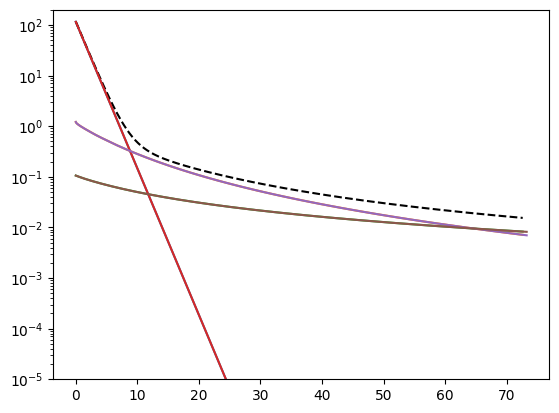

In [57]:
# Production Rates [grid]
P_true = np.array(Dome_C.COS_Production(h_acc/Dome_C.rho_ice))
#P_m = np.array(Dome_C.COS_Production(h_p/Dome_C.rho_ice))
#P_m = P_true @ delta_pa.T
P_m = P_true @ delta_ap_inv.T
#P_m[:,0]=P_true[:,0]
P = P0_tuning @ P_m
plt.plot(h_p, (P0_tuning[:,None]*P_m).T)
plt.plot(h_p, P, ls='--', c='k')
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pn'][:,-1])
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmu'][:,-1])
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmuf'][:,-1])
plt.yscale('log')
plt.ylim(1e-5,2e2)

In [54]:
P_m

array([[3.60550016e+02, 3.33217405e+02, 3.07956827e+02, ...,
        4.01242288e-19, 3.70824874e-19, 3.42713345e-19],
       [1.86149566e+01, 1.76661923e+01, 1.71188633e+01, ...,
        1.10684691e-01, 1.10235850e-01, 1.09789409e-01],
       [1.52171539e+00, 1.50069297e+00, 1.48116382e+00, ...,
        1.18786816e-01, 1.18552510e-01, 1.18318954e-01]])

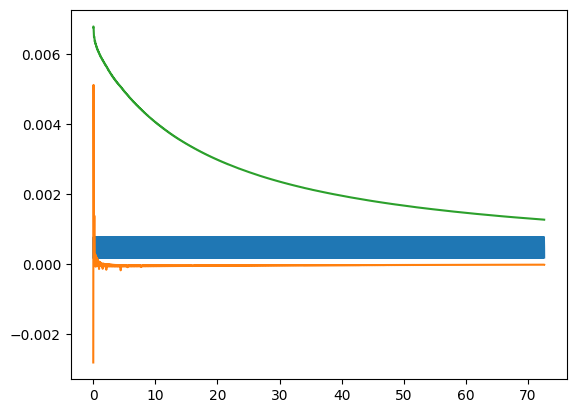

In [55]:
plt.plot(h_acc[h_acc<h_p[-1]], delta_ap[h_acc<h_p[-1]] @ P_m.T/Dome_C.COS_P[:len(h_acc)][h_acc<h_p[-1]]-1)

(1e-05, 200.0)

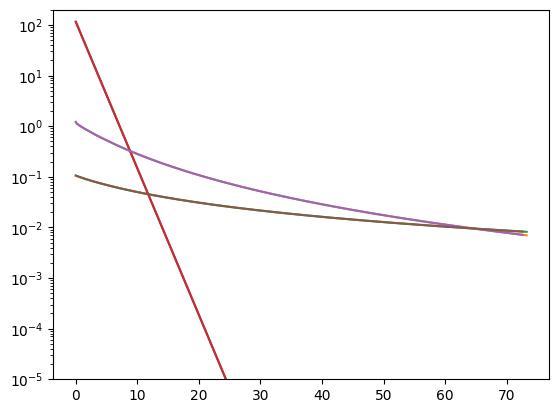

In [24]:
plt.plot(Dome_C.COS_z*Dome_C.rho_ice, P0_tuning[None,:]*Dome_C.COS_P)
plt.plot(h_p, (P0_tuning[:,None]*P_m).T)
plt.yscale('log')
plt.ylim(1e-5,2e2)

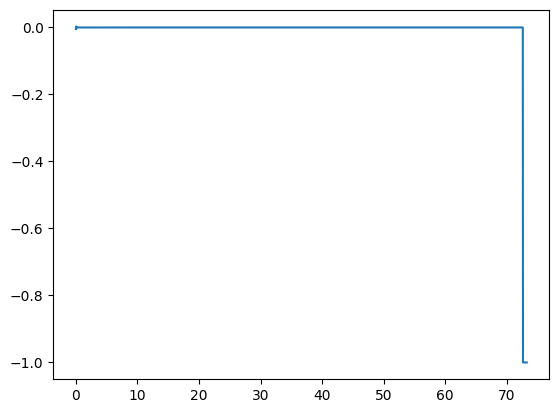

In [25]:
i=1
plt.plot(Dome_C.COS_z[:]*Dome_C.rho_ice, np.interp(Dome_C.COS_z*Dome_C.rho_ice, h_p, P0_tuning[i]*P_m[i], left=0, right=0) / (P0_tuning[i]*Dome_C.COS_P[:,i])-1)

In [26]:
# Output (Final) Depth [bins]
age_f_bins = np.arange(0, age_grid[-1]+1e-10, dt_p)
age_f = (age_f_bins[:-1]+age_f_bins[1:])/2
dage_f = np.diff(age_f_bins)

h_f_bins = np.interp(age_f_bins, age_grid, h_grid)
h_f = (h_f_bins[:-1]+h_f_bins[1:])/2
dh_f = np.diff(h_f_bins)

z_f_bins = np.interp(age_f_bins, age_grid, z_grid)
z_f = (z_f_bins[:-1]+z_f_bins[1:])/2
dz_f = np.diff(z_f_bins)

z_f.shape

(614,)

In [27]:
# Diffusion time resolution
# used to diffuse gas in firn
if Copy_Firn:
    dt_D = Dome_C.dt
else:
    dt_D = 0.01 #yrs
dt_D

0.01

In [28]:
# Diffusion Depths [grid]
# equally spaced in z
# used for calculating firn properties and diffusing gas in firn
if Copy_Firn:
    z = z_grid
    dz = smooth_diff(z)
    
    h = h_grid
    dh = smooth_diff(h)
    
    age = age_grid
    dage = smooth_diff(age)
else:
    dz = 0.25
    z = np.arange(0, z_grid[-1]+1e-10, dz)
    dz = smooth_diff(z)
    
    h = np.interp(z, z_grid, h_grid)
    dh = smooth_diff(h)
    
    age = np.interp(z, z_grid, age_grid)
    dage = smooth_diff(age)

z.shape

(441,)

In [29]:
# Sample Depths [bins]
# used to find average over depth ranges of ice core samples

sample_widths = np.array([20]*len(z_exp)) #widths of ice core sample depth ranges [m]

z_samp_bins = z_exp[None,:] + sample_widths[None,:]*np.array([-0.5,0.5])[:,None]
#z_samp_bins = Prop_DC.z_samp_bins
z_samp = (z_samp_bins[0]+z_samp_bins[1])/2
dz_samp = z_samp_bins[1]-z_samp_bins[0]

h_samp_bins = np.interp(z_samp_bins, z_grid, h_grid)
h_samp = (h_samp_bins[0]+h_samp_bins[1])/2
dh_samp = h_samp_bins[1]-h_samp_bins[0]

#axis0 - Lower/Upper Bound (0-lower, 1-upper)
#axis1 - Sample bin (s)
z_samp_bins.shape

(2, 16)

# Calculate Site Variables

## Density & Porosity Profile

Define the ice density profile of Dome C and the open, closed, total porosity $s$ with depth.

$$\rho(z) = dh(z)/dz$$

$$s(z) = 1-\rho(z)/\rho_{ice}$$

$$s_c(z) = 0.37s(z) * (\frac{s(z)}{1-\rho_{co}/\rho_{ice}})^{-7.6}$$

$$s_o(z) = s(z) - s_c(z)$$

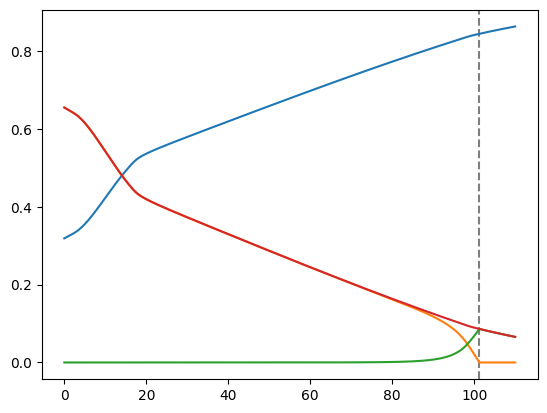

In [30]:
# Calculate Densities and Porosities

rho = dh/dz
if Copy_Firn:
    rho = Dome_C.rho
rho_ice = max(0.9165 - (Dome_C.T-273.15)*1.4438e-4 - (Dome_C.T-273.15)**2 * 1.5175e-7, max(rho)+1e-9) # Schwander et al.
rho_co = 0.833 # density at close off depth? idk

s = 1 - rho/rho_ice # porosity of ice by depth
s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
s_open = s - s_closed # open porosity

teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z,rho)
plt.plot(z,s_open)
plt.plot(z,s_closed)
plt.plot(z,s)

## Tortuosity & Diff_m

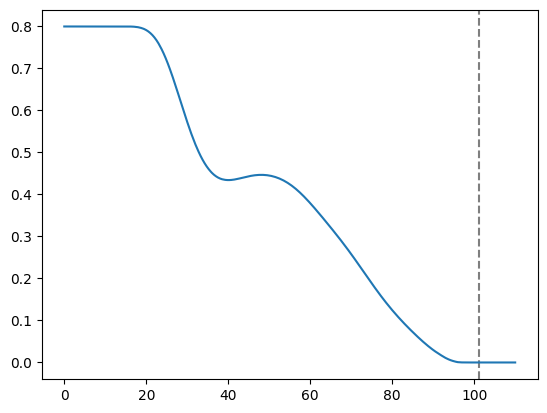

In [31]:
# Load InvTort and Diff_m from csv

tort_file = 'Firn_Model_Tortuosity_DomeC.csv'
Profiles = np.array(pd.read_csv(tort_file))
InvTort = np.interp(z, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
Diff_m = np.interp(z, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, InvTort)

## Bubble Pressure & Velocity

$$v_{ice}(z) = dz/dage = Acc/\rho$$

In the firn, we calculate the bubble pressure by the integral:

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z')/ (1+\int_{z'}^z \frac{d\ln v_{ice}(z'')}{dz''} dz'')dz'}{s(z)\int_0^z \frac{ds_c(z')}{dz'} dz'} $$

I can't help but notice we're taking the integral of derivatives here.  Makes it pretty easy to simplify,

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') /(1+\ln v_{ice}(z) - \ln v_{ice}(z'))dz'}{s(z)[s_c(z)-s_c(0)]}$$

We also calculate the flux of air through the close-off depth:

$$flux = b_p(z_{co+1}) s_c(z_{co+1}) v_{ice}(z_{co+1})$$

The velocity:

$$v(z) = \begin{cases}\displaystyle
\frac{flux - v_{ice} * b_p * s_c}{C * s_o} & <v_{ice}(z)\\
v_{ice}(z) & \text{else}
\end{cases}$$

And the air content:

$$a_c = 1000 * \frac{b_p(z_{co+1}) * s_c(z_{co+1})}{\rho(z_{co+1})} * \frac{pressure}{101325} * \frac{273.15}{T}$$

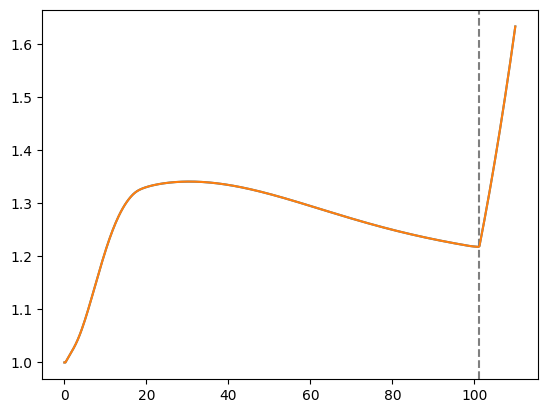

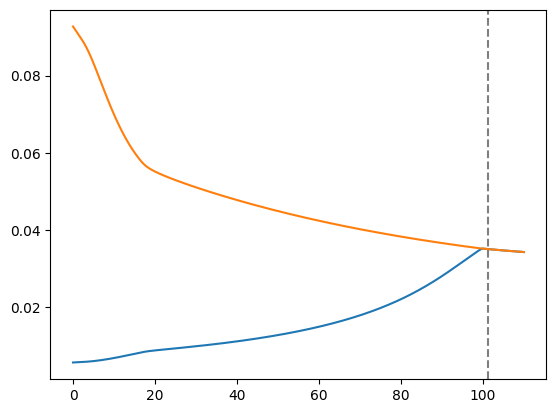

In [32]:
Site = Dome_C

g = Site.g
R = Site.R
T = Site.T
pressure = Site.pressure
M_air = Site.M_air
H_eddy = Site.H_eddy
D_0eddy = Site.D_0eddy

#dscl = smooth_diff(s_closed)/dz # ds_closed / dz
dscl = np.diff(s_closed, prepend=s_closed[0])/dz # ds_closed / dz

C_air = np.exp(M_air * g * z / (R * T) )
if Copy_Firn:
    Acc = Dome_C.Acc * Dome_C.rho_ice
else:
    Acc = np.mean(dh/dage)
v_ice = Acc / rho # downwards ice velocity
#v_ice = dz/dage

#strain = smooth_diff( np.log(v_ice))/dz # d log(v_ice) / dz
#strainsum = scipy.integrate.cumulative_trapezoid(strain, dx=self.dz, initial=0)
strainsum = np.log(v_ice)
i = np.arange(len(z))
bubble_pres = np.sum((dscl * C_air * s)[None,:] * dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(s*(s_closed-s_closed[0])).clip(min=1e-20)
# Divide by zero error at the first index, so we set that to 1
bubble_pres[0] = 1 # what are the units here??

# After teller_co:
bubble_pres[teller_co+1:] = bubble_pres[teller_co] * s[teller_co] / s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
# bubble pres is directly inverse to s and v_ice below close-off depth

flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * s_closed[teller_co+1]

velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air) )
velocity = velocity#/(60*60*24*365.25) # convert to m/s

#never used:
#air_content = 1000 * bubble_pres[teller_co+1] * s_closed[teller_co+1] * pressure / 101325 * 273.15 / T / rho[teller_co+1]

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, bubble_pres)
plt.plot(z, Dome_C.bubble_pres)
#plt.yscale('log')
plt.show()

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, velocity)#*(60*60*24*365.25))
#plt.plot(z, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air))
plt.plot(z, v_ice)
#plt.plot(z, Dome_C.v_ice)
plt.show()

## Crank Nicholson Parameters

The differential equation describing the diffusion of our open porosity gas concentration $c$ is:

$$\frac{\partial c}{\partial t} = \alpha\frac{\partial^2 c}{\partial z^2} + \beta\frac{\partial c}{\partial z} + \gamma c$$

where

$$\alpha = D + D_e$$

$$\beta = \frac{[D*(M_{air}-M_{^{14}CO}) + D_e*M_{air}]*g}{R*T} + \frac{d((D+D_e)*C_{air}*s_o)}{s_o*C_{air}\,dz} - v$$

$$\gamma = \frac{d(D*C_{air}*s_o)}{s_o*C_{air}\,dz}\frac{(M_{air}-M_{^{14}CO})*g}{R*T} - \lambda$$

$D = InvTort * D_{trace}$ - Diffusivity

$D_e$ - Eddie diffusivity

$C_{air} = e^{M_{air}gz/RT}$ - "Barometric equation", open porosity pressure relative to surface, I think?

$M_{air}$ - molar mass of air

$M_{trace}$ - molar mass of $^{14}$CO

$L_{trace}$ - decay rate of $^{14}$CO

The function below calculates $\alpha' = \alpha \frac{dt}{2dz^2}$, $\beta' = \beta \frac{dt}{4dz}$, and $\gamma' = \gamma \frac{dt}{2}$, for reasons that will be explained in the following section.

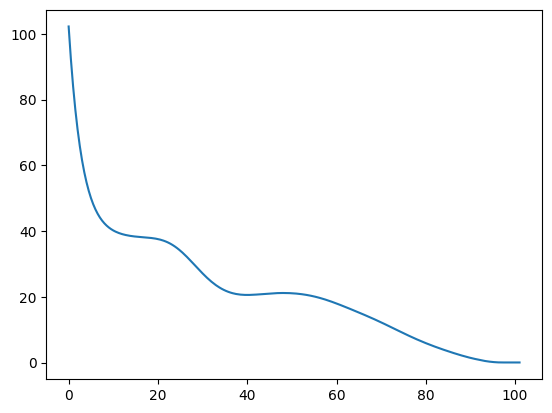

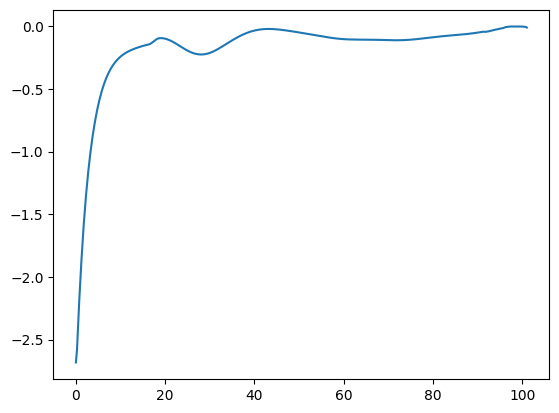

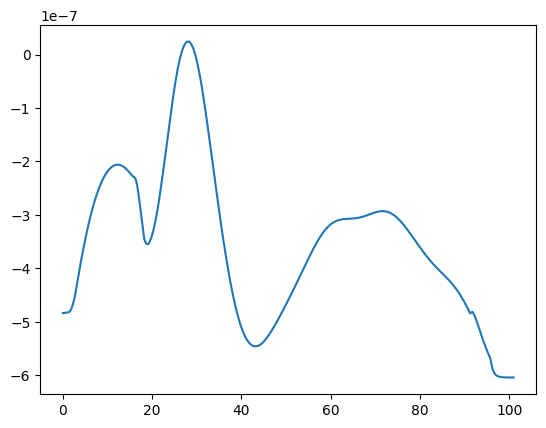

In [33]:
gas = 'C14_CO'
Site = Dome_C

L_trace = lambd/(60*60*24*365.25)
M_air = Site.M_air
g = Site.g
R = Site.R
T = Site.T

Q = teller_co

# Molecular diffusivity part:
Diff   =  InvTort * Site.D_gas[gas]

M_trace = Site.M_gas[gas]

# Eddy diffusivity part:
Diff_e = efilter(D_0eddy*np.exp(-z/H_eddy),0.5/np.diff(z))*(z<55) # Convection following Kawamura et al
Diff_e = np.maximum(Diff_e, Diff_m)    # Add dispersion in the LIZ

# Take the derivatives
porecl = smooth_diff(Diff*C_air*(s_open+1e-9))/dz/((s_open+1e-9)*C_air)#.clip(min=1e-20)
porecl_e = smooth_diff(Diff_e*C_air*(s_open+1e-9))/dz/((s_open+1e-9)*C_air)#.clip(min=1e-20)

porecl[teller_co]   = porecl[teller_co+1]
porecl_e[teller_co] = porecl_e[teller_co+1]

# c_t = alpha*c_zz + beta*c_z + gamma*c

alpha =  (dt_D*60*60*24*365.25/2/dz**2) * (Diff+Diff_e)
alpha2 =  (dt_D*60*60*24*365.25/2) * (Diff+Diff_e)
alpha2[1:-1] = alpha2[1:-1] / ((z[2:]-z[1:-1])*(z[1:-1]-z[:-2])*(z[2:]-z[:-2])/2)
alpha2[[0,-1]] = 0

beta  =  (dt_D*60*60*24*365.25/4/dz) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))
beta2  =  (dt_D*60*60*24*365.25/4/smooth_diff(z)) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))

gamma =  (dt_D*60*60*24*365.25/2) * (porecl*(M_air-M_trace)*g/(R*T) +  -L_trace)

plt.plot(z[:Q], alpha[:Q])
#plt.plot(z[:Q], alpha2[:Q]*(z[1:Q+1]-z[:Q]))
plt.show()

plt.plot(z[:Q], beta[:Q])
#plt.plot(z[:Q], beta2[:Q])
plt.show()

plt.plot(z[:Q], gamma[:Q])
plt.show()

## Crank-Nicholson Matrix

To solve the diffusion PDE:

$$\frac{\partial}{\partial t}c = \alpha\frac{\partial^2}{\partial z^2}c + \beta\frac{\partial}{\partial z}c + \gamma c$$

We approximate our spatial derivates as the average between timesteps $t+1$ and $t$:

$$\frac{c^{t+1}-c^t}{\Delta t} = \frac{\alpha}{2(\Delta z)^2}((c^{t+1}_{i+1}-2c^{t+1}_i+c^{t+1}_{i-1})+(c^t_{i+1}-2c^t_i+c^t_{i-1})) + \frac{\beta}{4\Delta z}((c^{t+1}_{i+1}-c^{t+1}_{i-1})+(c^t_{i+1}-c^t_{i-1})) + \frac{\gamma}{2}(c^{t+1}_i + c^{t}_i)$$

Moving our timesteps $t+1$ and $t$ to opposite sides of the equation,

$$-(\alpha' + \beta')c^{t+1}_{i+1} + (1 + 2\alpha' - \gamma')c^{t+1}_i - (\alpha' - \beta')c^{t+1}_{i-1} = (\alpha' + \beta')c^{t}_{i+1} + (1 - 2\alpha' + \gamma')c^{t}_i + (\alpha' - \beta')c^{t}_{i-1}$$

We can rewrite this as a matrix product on $c^{t+1}$ and $c^t$:

$$A_{i,i-1} = \alpha'_i - \beta'_i; \quad A_{i,i} = -2\alpha'_i + \gamma'_i; \quad A_{i,i+1} = \alpha'_i + \beta'_i$$

$$(I-A)c^{t+1} = (I+A)c^t$$

Which we can solve by inversion:

$$c^{t+1} = (I-A)^{-1}(I+A)c^t$$

The ice starts uniformly filled with the same $^{14}$CO concentration as the atmosphere.

After each timestep, the concentration at the top of the ice is set to the current atmospheric $^{14}$CO concentration.

Cosmogenic $^{14}$CO is also being injected into our gas, so after each timestep we add the extra $^{14}$CO leaking out of the grains.

In [34]:
Q = teller_co+20

#"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha[1:Q-1] - beta[1:Q-1], [0])),
        np.concatenate(([1], 1-2*alpha[1:Q-1]+gamma[1:Q-1], [0])),
        np.concatenate(([0], alpha[1:Q-1] + beta[1:Q-1] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha[1:Q-1] - beta[1:Q-1]), [-1])),
        np.concatenate(([1], 1+2*alpha[1:Q-1]-gamma[1:Q-1], [1])),
        np.concatenate(([0], -1*(alpha[1:Q-1] + beta[1:Q-1]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha2[1:Q-1]*(z[2:Q]-z[1:Q-1]) - beta2[1:Q-1], [0])),
        np.concatenate(([1], 1-alpha2[1:Q-1]*(z[2:Q]-z[:Q-2])+gamma[1:Q-1], [0])),
        np.concatenate(([0], alpha2[1:Q-1]*(z[1:Q-1]-z[:Q-2]) + beta2[1:Q-1] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha2[1:Q-1]*(z[2:Q]-z[1:Q-1]) - beta2[1:Q-1]), [-1])),
        np.concatenate(([1], 1+alpha2[1:Q-1]*(z[2:Q]-z[:Q-2])-gamma[1:Q-1], [1])),
        np.concatenate(([0], -1*(alpha2[1:Q-1]*(z[1:Q-1]-z[:Q-2]) + beta2[1:Q-1]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()
#"""

A_inv = np.linalg.inv(A_back)
D = A_inv @ A_for
D[0] = 0
D1 = np.copy(D)
D = np.linalg.matrix_power(D,int(dt_p/dt_D))
D.shape

(425, 425)

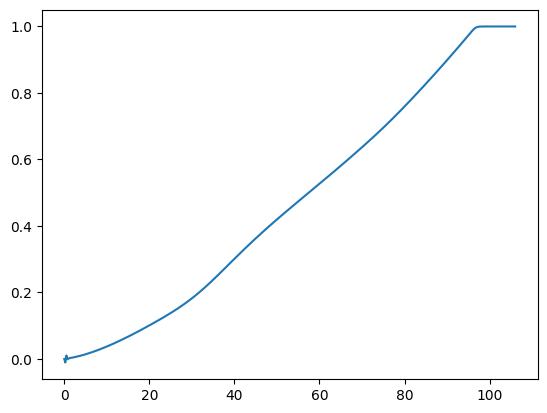

In [35]:
plt.plot(z[:Q], np.sum(D, axis=1))

In [36]:
N_D = int(1000/dt_acc) # maximum number of diffusion timesteps worth considering
D_t = np.moveaxis(cum_mat_prod(D,N_D),0,-1)
#D_t = np.moveaxis(cum_mat_prod(np.linalg.matrix_power(Dome_C.D,int(dt1/dt_D)),N_D),0,-1)
D_t.shape

100%|█████████████████████████████████████████████████████████████████████████████| 1999/1999 [00:01<00:00, 1246.73it/s]


(425, 425, 2000)

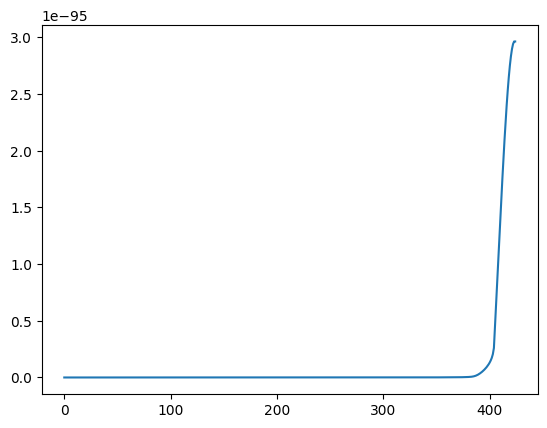

In [37]:
# after ~200 years only ~1e-6 of 14CO is left
# after ~300 years it's ~1e-9
plt.plot(np.sum(D_t[:,:,-1],axis=-1))

## Unit Conversions g<->ppm

/tmp/ipykernel_788/351948400.py:3: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)


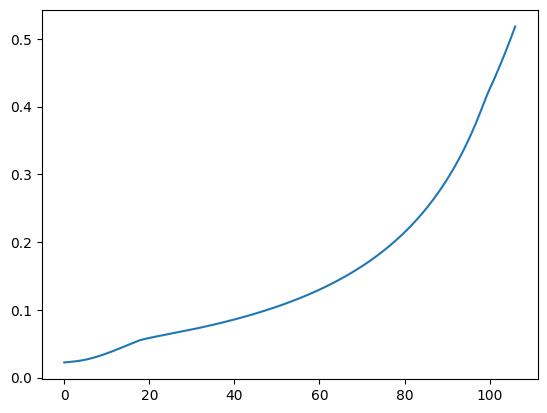

In [38]:
pressure = Dome_C.pressure

gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
gram_to_ppm[teller_co:] = 0

#U = (gram_to_ppm * (delta_pa @ delta_ap @ s_open)/(delta_pa @ delta_ap @ s))[:Q]
U = 1e18*R*T / (6.022140857e23*pressure*s[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
plt.plot(z[:Q], U)

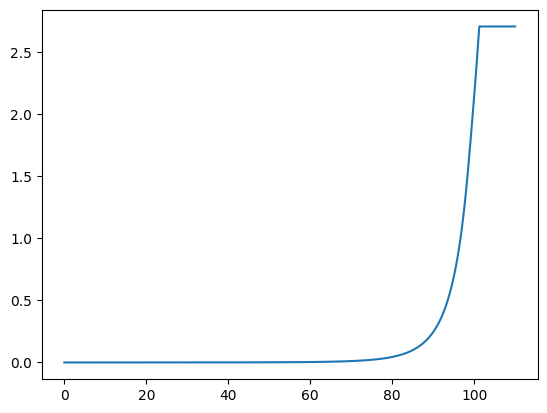

In [39]:
ppm_to_gram_cl = (6.022140857e23 * pressure * s_closed / rho * bubble_pres * 1e-6)/(1e18*R*T)
plt.plot(z, ppm_to_gram_cl)

## Trapping Rate

The trapping rate of open porosity gas into closed porosity gas is given by the change in the number density of closed porsosity gas particles per unit time:

$$trapping(z) = \rho(z)\frac{d(s_c*b_p)}{dz}$$

Since all of these new gas particles entering the closed porosity of our ice parcel come from the open porosity, the additional $^{14}$CO concentration ($c(z)$) they bring is the integral over time of the open porosity concentration ($c_o(z,t)$) times the trapping rate ($tr(z)$) times the fraction of $^{14}$C which has since decayed ($e^{-\lambda (t-t')}$), divided by the total gas in closed porosity ($\int_{t_0}^t tr(z(t'))\,dt'$).

$$c(z,t) = \frac{\int_{t_0}^{t} c_o(z(t'),t')\,tr(z(t'))\,e^{-\lambda (t-t')}\,dt'}{\int_{t_0}^t tr(z(t'))\,dt'}$$

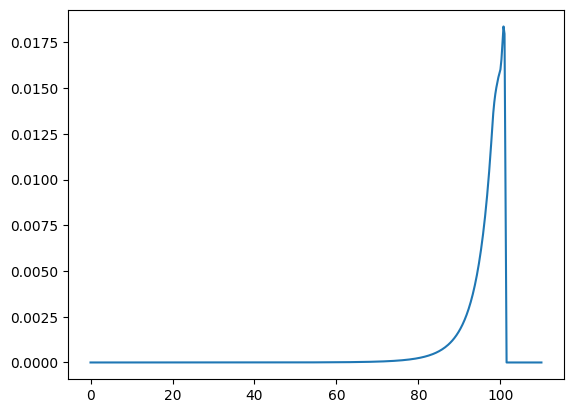

In [40]:
trapping_t = rho*smooth_diff(s_closed*bubble_pres/rho)/dz # Acc*rho_ice/v_ice = Acc*rho_ice/(Acc*rho_ice/rho) = rho
plt.plot(z, trapping_t)

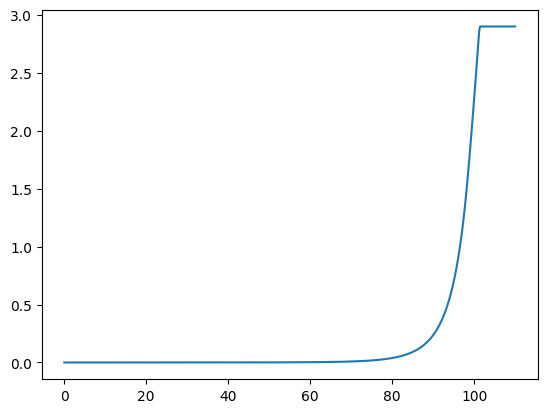

In [41]:
trapping_acc = np.interp(z_acc, z, trapping_t)
trapping_int = np.cumsum(trapping_acc*dt_acc)
plt.plot(z_acc, trapping_int)

## Interpolation Matrices

$\hat{H}$ - accumulation depth interpolation operator (interpolates production depths to h'(h,t))

$$H_i(h') = (\frac{h'-h_{i-1}}{h_i-h_{i-1}}).\text{clip}(0,1) - (\frac{h'-h_{i}}{h_{i+1}-h_{i}}).\text{clip}(0,1)$$

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present accumulation depth $h$

$h_i$ - propagation depths (for $i$<0 or $i$>max, replace the terms with $h'\geq h_0$ and $h'>h_{\text{max}}$, respectively)

Is the transpose the same as the inverse?

iff the matrix is orthonormal

In [42]:
#Interpolate from input time (t') to accumulation time (t'')
delta_at = interp_mat(t_acc[:,None],t_p[None,:])
#axis0 - 
#axis1 - 
delta_at.shape

(6000, 751)

In [43]:
#Interpolate from accumulation depths (a) to diffusion depths (d)
delta_da = interp_mat(z[:,None],np.array([0,*z_acc])[None,:])[:,1:]
#axis0 - diffusion depth (d)
#axis1 - accumulation depth (a)
delta_da.shape

(441, 4914)

In [44]:
#Interpolate from diffusion depths (a) to accumulation depths (d)
delta_ad = interp_mat(z_acc[:,None],z[None,:])
#axis0 - accumulation depth (a)
#axis1 - diffusion depth (d)
delta_ad.shape

(4914, 441)

In [45]:
delta_pd = interp_mat(z_p[:,None], z[None,:])
delta_pd.shape

(615, 441)

In [46]:
delta_dp = interp_mat(z[:,None], z_p[None,:])

In [47]:
delta_df = interp_mat(z[:,None],np.array([0,*z_f])[None,:])[:,1:]
delta_df.shape

(441, 614)

## Sample Average Matrix

$\hat{S}$ - sample operator (averages over each sample depth range in accumulation depth)

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - sample depth bins (+ upper bound, - lower bound)

$h$ - accumulation depth bins (- lower bound, $\Delta$ width)

In [48]:
def bin_average_mat(out_up, out_low, in_low, din):
    S = (out_up-in_low).clip(0,din) - (out_low-in_low).clip(0,din)
    return S/np.sum(S, axis=-1, keepdims=True)

In [49]:
S_fa = bin_average_mat(h_f_bins[1:,None],h_f_bins[:-1,None],h_acc_bins[None,:-1],dh_acc[None,:])
S_fa.shape

(614, 4914)

In [50]:
S_sf = bin_average_mat(h_samp_bins[1,:,None],h_samp_bins[0,:,None],h_f_bins[None,:-1],dh_f[None,:])
S_sf.shape

/tmp/ipykernel_788/3354869432.py:3: RuntimeWarning: invalid value encountered in divide
  return S/np.sum(S, axis=-1, keepdims=True)


(16, 614)

# Accumulation Tensors

## Grains

In tensor form:

$$\vec{c}^{\text{grains}}_a = \sum_{t',p}(\vec{R}\cdot \hat{A}^{\text{grains}})_{a,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'}$$

$$\hat{A}^{\text{grains}}_{r,a,p,t'} = (1-\vec{L}_r)^{-t'}e^{\lambda t'}dt' \hat{\delta}_{a+t',p}$$

where $\hat{\delta}_{a+t',p} = \hat{\delta}_{a,p'}\hat{\delta}_{p'+t',p}$ acts as a linear interpolation from depth $p$ to $a+t'$ (from $z^{prod}_p$ to $z(age(z_a)+t')$)

$\vec{L}_r$ - annual leakage rate of reservoir $r$

In [51]:
A_grains = (1-L[None,:])**(-t_p[:,None]+dt_p) * np.exp(lambd*(t_p[:,None]-dt_p)) * dt_p
#axis1 - production time (t1)
#axis0 - leakage rate (L)
A_grains.shape

(751, 2)

In [52]:
f = np.arange(len(z_f))
p = np.arange(len(z_p))
t = np.arange(len(t_p))-len(t_p)+1
delta_fpt = f[:,None,None] + t[None,None,:] == p[None,:,None]
delta_fpt2 = f[:,None,None] + t[None,None,:]+1 == p[None,:,None]
#axis0 - final depth (f)
#axis1 - production depth (p)
#axis2 - production time (t)
delta_fpt.shape

(614, 615, 751)

In [ ]:
#t = np.arange(len(t_p))-len(t_p)#+1

#A_grains_const = np.einsum('fpt, fpr, tr -> fpr', delta_fpt, A_grains_small, (1-L[None,:])**(-t[:,None]*dt_p) * np.exp(lambd*t[:,None]*dt_p) * dt_p, optimize=True)
#A_grains_const = np.einsum('fpt, tr -> fpr', delta_fpt, (1-L[None,:])**(-t[:,None]*dt_p) * np.exp(lambd*t[:,None]*dt_p) * dt_p, optimize=True)
A_grains_const = (delta_fpt @ A_grains + delta_fpt2 @ A_grains)/2
#axis0 - final depth (f)
#axis1 - production depth (p)
#axis2 - reservoir (r)
#A_grains_const.shape

In [51]:
#t = np.arange(len(t_acc))-len(t_acc)#+1
t = -np.arange(len(t_acc))-1
A_grains_const = np.zeros((len(z), len(z_p), len(L)))

for i in tqdm(t):
    A_grains_const += (delta_da[:,-i:] @ delta_ap[:i])[:,:,None] * (1-L[None,None,:])**(-i*dt_acc)* np.exp(lambd*i*dt_acc) * dt_acc
#axis0 - final depth (f)
#axis1 - production depth (p)
#axis2 - reservoir (r)
A_grains_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:57<00:00, 104.77it/s]


(441, 615, 2)

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

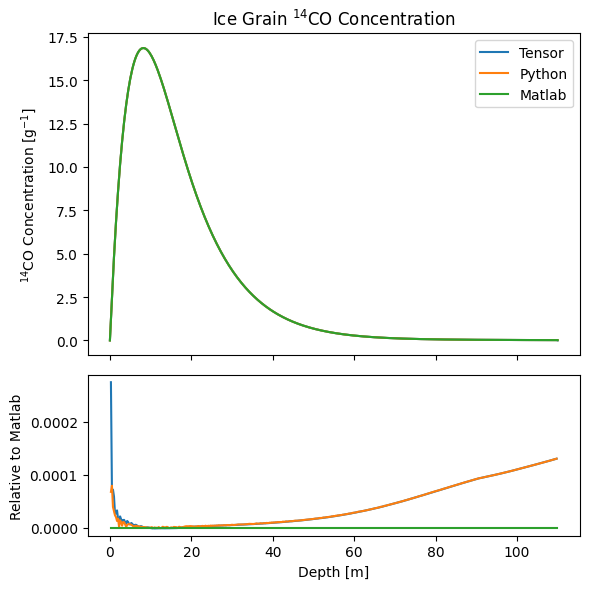

In [58]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])
c_grains = np.einsum('fpr, p, r -> f', A_grains_const, P, Res, optimize=True)
axes[0].plot(z, c_grains, label='Tensor')
axes[0].plot(Dome_C.z, P0_tuning @ C14_grains @ Res, label='Python')
axes[0].plot(runMat['z'], runMat['C14_grains'][:,-1,1], label='Matlab')
axes[0].legend()

axes[1].plot(z[1:-1], c_grains[1:-1]/runMat['C14_grains'][1:-1,-1,1]-1)
axes[1].plot(z[1:-1], (P0_tuning @ C14_grains @ Res)[1:-1]/runMat['C14_grains'][1:-1,-1,1]-1)
axes[1].plot(z[1:-1], runMat['C14_grains'][1:-1,-1,1]/runMat['C14_grains'][1:-1,-1,1]-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Ice Grain $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

## Open Porosity

$$\vec{c}^{open}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{open})_{a,p,t'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t'+t}$$

$$\hat{A}^{\text{open}}_{r,a,p,t'} = [\sum_{t''=0}^{\text{age}_{co}} (D^t U \hat{\delta}_{a,p})_{a,p+t'',-t'-t''} e^{-\lambda t''}(1-\vec{L}_r)^{t''}(1-(1-\vec{L}_r)^{dt''})]dt'$$

$t''$ - leak time; time spent in grain before leaking into open pores, can't be longer than age at close-off depth

$p+t''$ - leak depth; depth at which 14CO produced at depth $p$ leaks into open pores ($z^{prod}_{p+t''}=z(age(z^{prod}_p)+t'')$ since $z^{prod}$ corresponds to $t''$)

$-t'-t''$ - diffusion time; time spent diffusing in open porosity before measurement

$\vec{L}_r$ - annual leakage rate of reservoir $r$

$\hat{\delta}_{a,p}$ - linear interpolation from production depth $p$ to accumulation depth $a$

$$D^t_{a,a',t'''} = [\sum_{t_D=0}^{dt'''} D^{t_D} \frac{dt_D}{dt'''}]D^{t'''}$$

$D^t_{a,a',t'''}$ - Diffusion of 14CO introduced at depth $a'$ to depth $a$, for a duration averaged between $t'''$ and $t'''+dt'''$ years, with subdivided timestep $dt_D$

$D^{dt}$ - Diffusion matrix for timestep $dt$

$$U_a = U_{g\rightarrow ppm}(a) \frac{s_o(a)}{s(a)}$$

$U(a)$ - open porosity fraction * unit conversion from per gram to ppm at depth $a$

In [56]:
#Interpolate from production depths (p) to past accumulation depths (a'=a+At)
#dt2 = dt1
#t2 = np.arange(int(age[Q]/dt2))*dt2
#h_hist = np.interp(age[None,:Q,None] - t2[:,None,None], age_grid, h_grid, left=-10)
#delta_pahist = interp_mat(h_hist, p[None,p<=h[teller_co+1]])
#axis0 - grain time (t2)
#axis1 - past accumulation depth (a')
#axis2 - production depth (p)
#delta_pahist.shape

In [64]:
# apply our unit conversion ahead of time
# to avoid repetitive multiplication
co_acc = len(h_acc[h_acc<=h[teller_co+1]])
co_p = len(h_p[h_p<=h[teller_co+1]])
DU = delta_ap[:Q,:co_p].T @ ((np.sum(cum_mat_prod(D1,int(dt_p/dt_D)), axis=0).T @ D_t)*gram_to_ppm[None,:,None] * dt_D/dt_p) * ((delta_pd @ s_open)/(delta_pd @ s).clip(min=1e-20))[None,:co_p,None]
#DU = np.sum(DU, axis=-1)
#axis0 - accumulation depth (a)
#axis1 - diffusion depth (p')
#axis2 - diffusion time (t3=-t1-t2)

100%|███████████████████████████████████████████████████████████████████████████████| 399/399 [00:00<00:00, 1413.46it/s]


In [59]:
A_open_atm = np.sum(cum_mat_prod(D1,int(dt_p/dt_D)), axis=0)[:,0] @ D_t[:,:,::-1]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_open_atm.shape

100%|███████████████████████████████████████████████████████████████████████████████| 399/399 [00:00<00:00, 1202.59it/s]


(425, 2000)

In [67]:
# sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
A_open = np.zeros((len(L),Q,co_p,int(age[Q]/dt_p)+N_D))
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)

dt2 = dt_p
t2 = np.arange(int(age[Q]/dt2))*dt2
for t2 in tqdm(range(len(t2))): #t2 = time spent in grains before leaking
    A_open[:,:,:-t2 if t2>0 else None,t2:t2+N_D] += DU[None,:,t2:,::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
    #A_open[:,:,:,t2:t2+N_D] += delta_pahist[t2].T @ DU[None,:,:,::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
A_open *= (1-(1-L)**dt2)[:,None,None] * dt_p

#t1_cut = t1[-int(age[Q]/dt1):]
#dt3 = dt1
#for t3 in tqdm(range(N_D)):
    #A_open[:,:,:,N_D-t3-1:-t3-1] += np.moveaxis(DU[:,:,t3] @ delta_pahist[N_D-t3-1:-t3-1], 0,-1)[None,:,:,:] * (np.exp(lambd*(t1_cut[None,:]+t3*dt3)) * (1-L[:,None])**(-(t1_cut[None,:]+t3*dt3)))[:,None,None,:]
#A_open *= (1-(1-L)**dt3)[:,None,None,None] * dt1
#A_open = delta_pa.T[:,:Q] @ A_open
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_open.shape

  2%|█▎                                                                                 | 9/587 [00:34<36:46,  3.82s/it]


KeyboardInterrupt: 

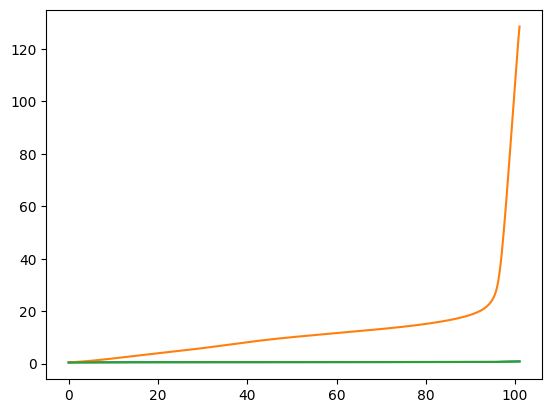

In [63]:
plt.plot(Dome_C.z[:Dome_C.teller_co], P0_tuning @ (c_gases[:Dome_C.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Dome_C.teller_co,0])
plt.plot(z[:teller_co], (A_open[:,:teller_co]@P[:co_p]).T @ Res + A_open_atm[:teller_co] @delta_at[-N_D:] @ gas_history)
plt.plot(runMat['z'], runMat['c_open'][:,-1])

## Closed Porosity

$$\vec{c}^{closed}_{a,t} = \sum_{t',p} (\vec{R}\cdot[\hat{A}^{closed} + \hat{A}^{trap}])_{a,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t+t'} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t+t'}$$

$$\hat{A}^{\text{closed}}_{r,a,p,t'} = e^{\lambda t'}dt'\sum_{t''=0}^{-t'}\frac{s_c(p+t'')}{s(p+t'')}(1-L)^{t''}(1-(1-L)^{dt''}) \hat{\delta}_{p,a+At'}$$

$t''$ - leak time (relative to production)

In [48]:
dt2 = dt1
t2 = t1-t1[0]

i = np.arange(len(p))
j = np.arange(len(t2))
sc_cast = ((delta_ap @ s_closed)/(delta_ap @ s).clip(min=1e-20))[(i[:,None]+j[None,:]).clip(max=len(p)-1)]*(i[:,None]+j[None,:]<=len(p)-1)#/s_cast # closed leak fraction at leak time
#axis0 - production depth (p)
#axis1 - grain time (t2)

A_closed = np.cumsum(
    sc_cast[None,:,:] * (1-L[:,None,None])**t2[None,None,:],
    axis=-1
)[:,:,::-1] * (1-(1-L)**dt2)[:,None,None] * np.exp(lambd * t1)[None,None,:] * dt1
#axis0 - Leakage rate (L)
#axis1 - production depth (p)
#axis2 - production time (t1)
A_closed.shape

(2, 836, 1001)

In [49]:
A_closed_const = np.einsum('ai, tip, lpt -> lap', delta_pa, delta_ppt1, A_closed, optimize=True)

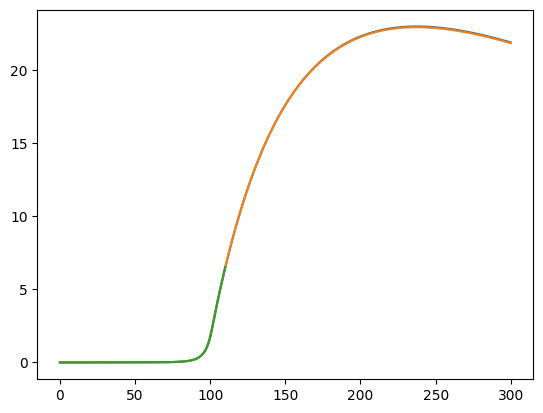

In [50]:
plt.plot(z, (A_closed_const @ P).T @ Res)
plt.plot(Dome_C.z, P0_tuning @ (C14_cumuleak_closed) @ Res)
plt.plot(runMat['z'], runMat['C14_closed'][:,-2,1])

$$\hat{A}^{trap}_{l,a,p,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}^{-t'}e^{-\lambda t''}Tr(a,t'')\hat{\delta}_{a',a-At''}\hat{A}^{open}_{l,a',p,-t'-t''}dt''$$

$$\hat{A}^{atm}_{a,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}e^{-\lambda t''}Tr(a,t'')\hat{\delta}_{a',a-At''}\hat{A}^{atm}_{a',-t'-t''}dt''$$

$t''$ - time in closed grain after getting trapped

Note: I think $U_{ppm\rightarrow g}$ should be applied at trapping depth, but in the firn model it is applied at final depth

In [51]:
A_trap_atm = np.zeros((len(z), len(t1)+N_D))
dt2 = dt1
t2 = t1-t1[0]
A_atm_interp = interp1d(z[:Q], A_open_atm, axis=0, bounds_error=False, fill_value=0, assume_sorted=True)
z_hist = np.interp(age[None,:] - t2[:,None], age, z, left=-10)

for t2 in tqdm(range(len(t2))):
    A_trap_atm[:,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * M_Trap[:,None,t2] * A_atm_interp(z_hist[t2])[:,::-1] * dt2
A_trap_atm *= ppm_to_gram_cl[:,None]
A_trap_atm[:,len(t1)-1] += np.sum(A_trap_atm[:,len(t1):],axis=-1)
A_trap_atm = A_trap_atm[:,:len(t1)]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_trap_atm.shape

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 1154.98it/s]


(1201, 1001)

In [52]:
N_op = A_open.shape[-1]
A_trap = np.zeros((len(L), len(z), len(p), len(t1)+N_op))
p_lim = len(p[p<=h[teller_co+1]])
dt2 = dt1
t2 = t1-t1[0]
A_open_interp = interp1d(z[:Q], A_open, axis=1, bounds_error=False, fill_value=0, assume_sorted=True)
z_hist = np.interp(age[None,:] - t2[:,None], age, z, left=-10)

for t2 in tqdm(range(len(t1))):
    A_trap[:,:,:p_lim,t2:t2+N_op] += np.exp(-lambd*t2*dt2) * M_Trap[None,:,None,None,t2] * A_open_interp(z_hist[t2])[:,:,:,::-1] * dt2
A_trap *= ppm_to_gram_cl[None,:,None,None]
A_trap[...,len(t1)-1] += np.sum(A_trap[...,len(t1):],axis=-1)
A_trap = A_trap[...,:len(t1)]
#axis0 - Leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_trap.shape

100%|███████████████████████████████████████████████████████████████████████████████| 1001/1001 [47:39<00:00,  2.86s/it]


(2, 1201, 836, 1001)

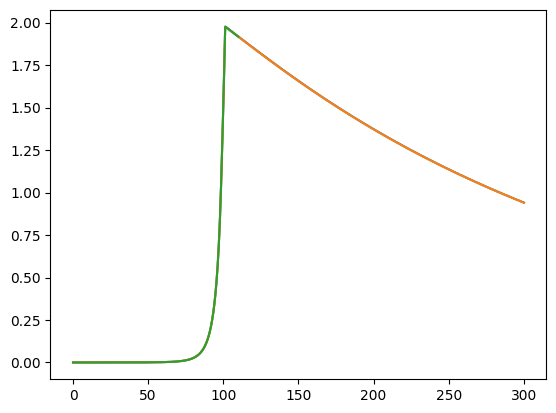

In [53]:
plt.plot(z, Res @ np.sum(A_trap, axis=-1)@P + A_trap_atm @ gas_history)
plt.plot(Dome_C.z, P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])
plt.plot(runMat['z'], runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])

## Total Concentration

$$\hat{A}_{r,s,p,t'} = \hat{S}_{s,a}\cdot[\hat{A}^{grains}+\hat{A}^{closed}+\hat{A}^{trap}]_{r,a,p,t'}$$

$$\hat{A}^{atm}_{s,t'} = \hat{S}\cdot \hat{A}^{atm}$$

$$\vec{c}^{pred}_s = \sum_{t',p} (\vec{R}\cdot\hat{A})_{s,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'} + \sum_{t'}\hat{A}^{atm}_{s,t'}\vec{c}_{t'}^{atm}$$

$$\Sigma^{pred}_{ss'} = (\vec{R} \hat{A}\vec{\phi})_{s,p}(\vec{f}\Sigma^{prod}\vec{f}^T)_{p,p'}(\vec{R} \hat{A}\vec{\phi})^T_{p',s'} + (\hat{A}^{atm})_{s,t}\Sigma^{atm}_{t,t'}(\hat{A}^{atm})^T_{t',s'}$$

In [90]:
A_profile = A_grains_const + A_closed_const + np.sum(A_trap,axis=-1)
A_total = np.einsum('sa, la...->ls...', S_mat, A_profile)
A_total.shape

(2, 16, 836)

In [91]:
A_atm = S_mat @ A_trap_atm
A_atm.shape

(16, 1001)

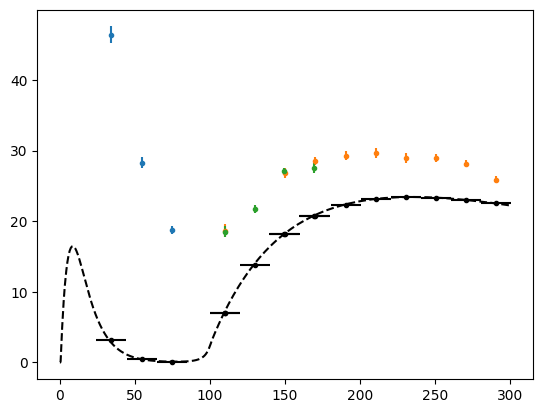

In [97]:
c_pred = Res @ (A_total @ P)
plt.plot(z, Res @ (A_profile @ P), ls='--', c='k')
plt.errorbar(z_samp, c_pred, fmt='.', xerr=dz_samp/2, c='k')
for i in range(3):
    plt.errorbar(z_exp[i_samples[i]:i_samples[i+1]], CO_exp[i_samples[i]:i_samples[i+1]], yerr=dCO_exp[i_samples[i]:i_samples[i+1]], fmt='.')